<a href="https://colab.research.google.com/github/fergogu27-ctrl/EDPII/blob/main/Simulacion_TIBASA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **METODO DE LA TRANSFORMADA INVERSA**

La empresa TIBASA (Fabricante de tinas de baño) tiene asignado un camión especial para el transporte de tinas terminadas. Dicho camión transporta diariamente 5 tinas. El peso de cada tina sigue la distribución triangular de la imagen anexa.

Si la capacidad del camión es de 1 tonelada, ¿cuál es la probabilidad de que el peso de las tinas exceda la capacidad del camión?

SOLUCION:
La empresa TIBASA transporta diaraiamente 5 tinas en un camion con capacidad de 1 tonelada: $$1000\text{ kg}.$$
El peso de cada tina sigue una distribución triangular con soporte de 190 kg a 230 kg y moda en 210 kg.

Se desea estimar por simulación:

$$
P(X_1+X_2+X_3+X_4+X_5>1000).
$$

La metodología utilizada de la clase es la siguiente: primero se obtiene la función acumulada $F(x)$, después se calcula la inversa $F^{-1}(R)$ y finalmente se simulan valores usando $R\sim U(0,1)$.

## 1. Densidad del peso de una tina

De la gráfica, la densidad es triangular:

$$
f(x)=
\begin{cases}
\dfrac{x-190}{400}, & 190\leq x\leq 210,\\[6pt]
\dfrac{230-x}{400}, & 210<x\leq 230,\\[6pt]
0, & \text{en otro caso.}
\end{cases}
$$

La altura máxima ocurre en $x=210$:

$$
f(210)=\frac{210-190}{400}=\frac{20}{400}=\frac{1}{20}.
$$

Esto coincide con la gráfica, porque el área del triángulo es:

$$
\frac{\text{base}\cdot \text{altura}}{2}
=\frac{40\cdot \frac{1}{20}}{2}=1.
$$

## 2. Función de distribución acumulada

Calculamos:

$$
F(x)=P(X\leq x)=\int_{-\infty}^{x}f(t)\,dt.
$$

Para $190\leq x\leq 210$:

$$
F(x)=\int_{190}^{x}\frac{t-190}{400}\,dt
=\frac{(x-190)^2}{800}.
$$

Para $210<x\leq 230$:

$$
F(x)=1-\int_x^{230}\frac{230-t}{400}\,dt
=1-\frac{(230-x)^2}{800}.
$$

Por lo tanto:

$$
F(x)=
\begin{cases}
0, & x<190,\\[4pt]
\dfrac{(x-190)^2}{800}, & 190\leq x\leq 210,\\[8pt]
1-\dfrac{(230-x)^2}{800}, & 210<x\leq 230,\\[8pt]
1, & x>230.
\end{cases}
$$

Notamos que:

$$
F(210)=\frac{(210-190)^2}{800}=\frac{400}{800}=\frac12.
$$

Eso separa la fórmula inversa en dos casos.

## 3. Método de la transformada inversa

Sea:

$$
R\sim U(0,1).
$$

Igualamos:

$$
F(x)=R.
$$

### Primer caso: $0\leq R\leq \frac12$

$$
\frac{(x-190)^2}{800}=R.
$$

Entonces:

$$
(x-190)^2=800R.
$$

Como $x\geq 190$, tomamos la raíz positiva:

$$
x=190+\sqrt{800R}.
$$

### Segundo caso: $\frac12<R\leq 1$

$$
1-\frac{(230-x)^2}{800}=R.
$$

Entonces:

$$
\frac{(230-x)^2}{800}=1-R.
$$

$$
(230-x)^2=800(1-R).
$$

Como $x\leq 230$, despejamos:

$$
x=230-\sqrt{800(1-R)}.
$$

Por lo tanto, el generador queda:

$$
X=
\begin{cases}
190+\sqrt{800R}, & 0\leq R\leq \frac12,\\[8pt]
230-\sqrt{800(1-R)}, & \frac12<R\leq 1.
\end{cases}
$$


## 4. Algoritmo de simulación

Para cada día simulado:

1. Generar 5 números aleatorios $R_1,R_2,R_3,R_4,R_5\sim U(0,1)$.
2. Transformar cada $R_i$ en un peso $X_i$ usando la fórmula inversa.
3. Calcular el peso total:

$$
S=X_1+X_2+X_3+X_4+X_5.
$$

4. Verificar si:

$$
S>1000.
$$

5. Repetir muchas veces.
6. Estimar la probabilidad mediante frecuencia relativa:

$$
\widehat{p}=\frac{\text{número de días donde }S>1000}{\text{número total de días simulados}}.
$$


In [1]:
import random as r
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def peso_tina():
  R = r.random()                        # Generamos un número aleatorio R con distribución uniforme en el intervalo (0,1).
  if R <= 0.5:
    X = 190 + np.sqrt(800*R)
  else:
    X = 230 - np.sqrt(800*(1-R))
  return X                              # Devuelve el peso simulado de una tina.

Simulacion de un dia

Un dia por el problema sabemos que equivale a transportar 5 tinas, por lo tanto generamos 5 pesos y los sumamos.

In [3]:
def sim_dia():
  pesos = [peso_tina() for i in range(5)]
  peso_total = sum(pesos)

  return pesos, peso_total

Ahora repetimos la simulacion de muchos dias para sumarla y calcular la probabilidad

In [4]:
N = 10000
l = 0
totales= []

for dia in range(N):
  pesos, total = sim_dia()
  totales.append(total)


  if total > 1000:
    l += 1

proba_estimada = l/N
print(proba_estimada)

0.9981


In [5]:
print(f"Días en que se excedió la capacidad: {l}")
print(f"Probabilidad estimada de exceder 1000 kg: {proba_estimada:.6f}")
print(f"Probabilidad estimada en porcentaje: {100*proba_estimada:.4f}%")


Días en que se excedió la capacidad: 9981
Probabilidad estimada de exceder 1000 kg: 0.998100
Probabilidad estimada en porcentaje: 99.8100%


Gráfica de la densidad triangular

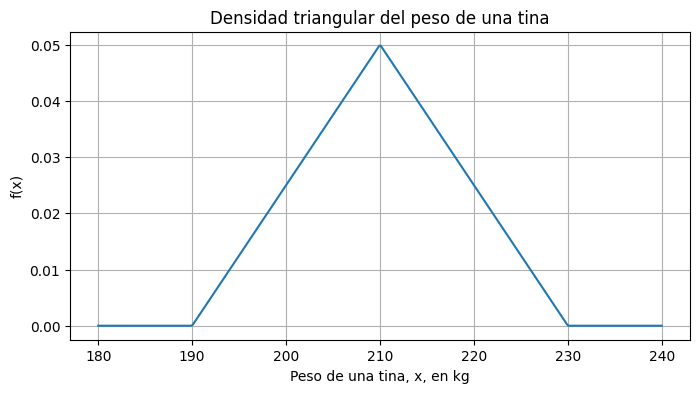

In [6]:
def f_triangular(x):          # Creamos una función para evaluar la densidad triangular en un punto x.

    if 190 <= x <= 210:
        return (x - 190) / 400

    elif 210 < x <= 230:
        return (230 - x) / 400

    else:
        return 0

x_valores = np.linspace(180, 240, 400)
y_valores = [f_triangular(x) for x in x_valores]
plt.figure(figsize=(8, 4))
plt.plot(x_valores, y_valores)
plt.title("Densidad triangular del peso de una tina")
plt.xlabel("Peso de una tina, x, en kg")
plt.ylabel("f(x)")
plt.grid(True)
plt.show()

Ahora hacemos el histograma de pesos en N dias

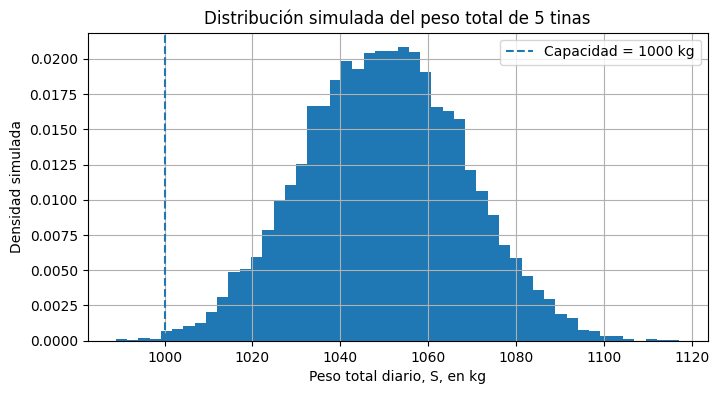

In [7]:
totales = np.array(totales)

plt.figure(figsize=(8, 4))
plt.hist(totales, bins=50, density=True)
plt.axvline(1000, linestyle="--", label="Capacidad = 1000 kg")
plt.title("Distribución simulada del peso total de 5 tinas")
plt.xlabel("Peso total diario, S, en kg")
plt.ylabel("Densidad simulada")
plt.legend()
plt.grid(True)
plt.show()

 Conclusión

Con $N=10000$ días simulados, la estimación obtenida es aproximadamente:

$$
\widehat{p}\approx 0.9975.
$$

Por lo tanto, la probabilidad de que el peso de las 5 tinas exceda la capacidad de 1 tonelada es aproximadamente:

$$
99.75\%.
$$

Esto significa que, bajo este modelo, casi todos los días el camión excedería la capacidad de 1000 kg, porque el peso promedio de una tina es 210 kg y el peso promedio de 5 tinas es:

$$
5(210)=1050\text{ kg}.
$$


Por ultimo calculamos la probabilidad analíticamente usando el Teorema del Límite Central

In [17]:
a = 190    # peso minimo
b = 230    # peso maximo
c = 210    # moda
n = 5      # tinas transportadas
cap = 1000 #capacidad del camion kg
N = 10000
confianza = 0.95
z_alpha = 1.96

In [18]:
M = (a + b + c) / 3       #Calculamos la media de la distribucion triangular

In [19]:
varianza = (a**2 + b**2 + c**2 - a*b - a*c - b*c) / 18    #Calculamos la varianza
sigma = np.sqrt(varianza)
M_sum = n * M
v_sum = n * varianza
s_sum = np.sqrt(v_sum)
z = (cap - M_sum) / s_sum

In [20]:
import math
def Phi(z):
    return 0.5 * (1 + math.erf(z / np.sqrt(2)))
probabilidad = 1 - Phi(z)

In [21]:
error = np.sqrt(probabilidad * (1 - probabilidad) / N)
margen = z_alpha * error
l_i = probabilidad - margen
l_s = probabilidad + margen

In [22]:
print("Media de una tina:", M)
print("Varianza de una tina:", varianza)
print("Desviación estándar de una tina:", sigma)

print("\nMedia de la suma de 5 tinas:", M_sum)
print("Varianza de la suma de 5 tinas:", v_sum)
print("Desviación estándar de la suma:", s_sum)

print("\nValor de Z:", z)
print("Probabilidad de exceder 1000 kg:", probabilidad)
print("Probabilidad en porcentaje:", probabilidad * 100, "%")

print("\n Error:",error)
print("Margen de error:",margen)
print("Limite inferior:",l_i)
print("Limite superior:",l_s)

Media de una tina: 210.0
Varianza de una tina: 66.66666666666667
Desviación estándar de una tina: 8.16496580927726

Media de la suma de 5 tinas: 1050.0
Varianza de la suma de 5 tinas: 333.33333333333337
Desviación estándar de la suma: 18.257418583505537

Valor de Z: -2.7386127875258306
Probabilidad de exceder 1000 kg: 0.9969150503397279
Probabilidad en porcentaje: 99.69150503397279 %

 Error: 0.000554565843328423
Margen de error: 0.001086949052923709
Limite inferior: 0.9958281012868042
Limite superior: 0.9980019993926517


 Conclusión

Con $N=10000$ enla solucion analitica, la estimación obtenida es aproximadamente:

$$
\widehat{p}\approx 0.9969.
$$

Por lo tanto, la probabilidad de que el peso de las 5 tinas exceda la capacidad de 1 tonelada es aproximadamente:

$$
99.69\%.
$$

Esto significa que, bajo este modelo, casi todos los días el camión excedería la capacidad de 1000 kg, porque el peso promedio de una tina es 210 kg y el peso promedio de 5 tinas es:

$$
5(210)=1050\text{ kg}.
$$


Para terminar el intervalo de confianza al 95% queda:
$$IC_{95\%}=(0.99657, 0.99726)$$
$$IC_{95\%}=(99.657\%, 99.726\%)$$
